<a href="https://colab.research.google.com/github/Joana123-collab/Data-Science-I/blob/main/20250412ProyectoI_DataScienceI_JoanaMuchut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📋 Predicción de empresas en quiebra 🏦

Para este análisis se utilizó un dataset público obtenido de Kaggle, que contiene información financiera detallada de empresas, incluyendo 95 indicadores financieros. Estos indicadores abarcan métricas de rentabilidad (como el ROA), liquidez (como el ratio de liquidez corriente), apalancamiento y otros parámetros contables relevantes. El objetivo es analizar si estas variables permiten anticipar la probabilidad de quiebra de una empresa.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Enlace público de Github
url= "https://github.com/Joana123-collab/Data-Science-I/raw/refs/heads/main/DISTRESSDATASET_DATASCIENCE.csv"
df = pd.read_csv(url, on_bad_lines= 'skip', sep=',', encoding='latin-1')

# Mostramos las primeras filas
print(df.head())

   ¿En quiebra?  \
0             1   
1             1   
2             1   
3             1   
4             1   

    ROA(C): Retorno sobre activos (antes de intereses y depreciación)  \
0                                           0.370594                    
1                                           0.464291                    
2                                           0.426071                    
3                                           0.399844                    
4                                           0.465022                    

    ROA(A): Retorno sobre activos (antes de impuestos)  \
0                                           0.424389     
1                                           0.538214     
2                                           0.499019     
3                                           0.451265     
4                                           0.538432     

    ROA(B): Retorno sobre activos (después de impuestos)  \
0                                    

# ✍**Problema:**

Predecir si una empresa entrará en quiebra basándose en 95 indicadores financieros.

# 🎯**Objetivo:**

Construir un modelo de clasificación que identifique empresas en riesgo con un Recall > 85% (priorizando detectar la mayor cantidad de quiebras posibles).

# 🤔**Hipótesis:**

**H1)** Las variables relacionadas con **deuda ** (X36 - Deuda Total/Patrimonio Neto), **liquidez** (X33 - Ratio de Liquidez Corriente) y **rentabilidad** (X1 - ROA) serán las más relevantes para predecir quiebras.

**H2)** Es posible predecir la quiebra de las empresas con una precisión superior al 75% y un AUC superior a 0.5 utilizando las características proporcionadas y un modelo de Random Forest.


Proporción de quiebras:
 ¿En quiebra?
0    0.967737
1    0.032263
Name: proportion, dtype: float64


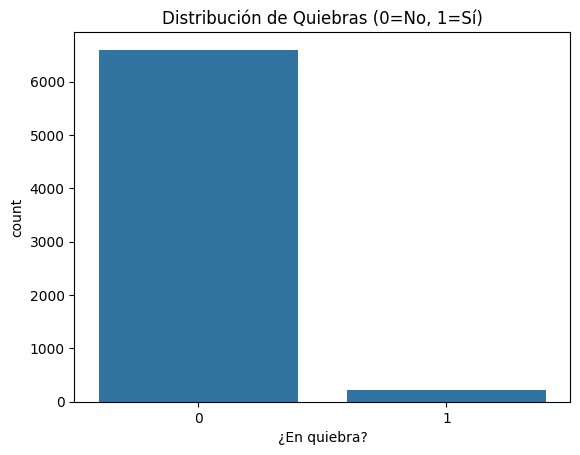

In [2]:
#Variable objetivo
sns.countplot(x='¿En quiebra?', data=df)
plt.title("Distribución de Quiebras (0=No, 1=Sí)")
print("\nProporción de quiebras:\n", df['¿En quiebra?'].value_counts(normalize=True))

Revisión de nulos:
Patrimonio/Pasivos    100.0
dtype: float64


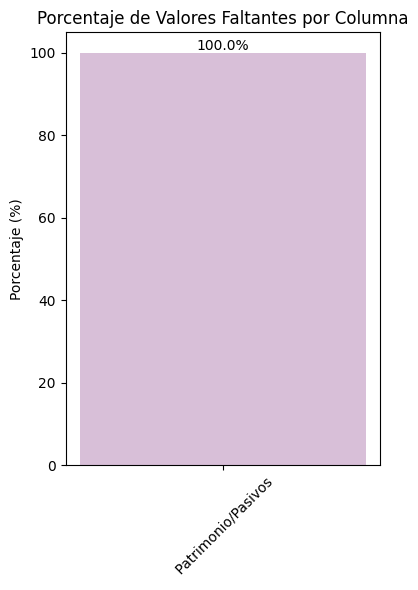

In [3]:
import matplotlib.pyplot as plt

# Revisión de nulos
print("Revisión de nulos:")
null_pct = df.isnull().mean() * 100
null_pct = null_pct[null_pct > 0]

if null_pct.empty:
    print("No se encontraron valores nulos en las columnas.")
else:
    print(null_pct)  # Opcional: mostrar % de nulos por columna

    # Gráfico si hay nulos
    plt.figure(figsize=(4, 6))
    lila_pastel = (216/255, 191/255, 216/255)
    bars = plt.bar(null_pct.index, null_pct, color=lila_pastel)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}%', ha='center', va='bottom')

    plt.title('Porcentaje de Valores Faltantes por Columna')
    plt.xticks(rotation=45)
    plt.ylabel('Porcentaje (%)')
    plt.tight_layout()
    plt.show()


In [4]:
#Buscamos y eliminamos columnas nulas
# Dataset original
print("Shape original:", df.shape)

# Eliminar columna
df_clean = df.drop(columns=[' Patrimonio/Pasivos'], errors='ignore')

# Verificación
print("Shape después de limpieza:", df_clean.shape)
print("Columna eliminada:", list(set(df.columns) - set(df_clean.columns)))

Shape original: (6819, 97)
Shape después de limpieza: (6819, 96)
Columna eliminada: [' Patrimonio/Pasivos']



Top 15 variables correlacionadas con quiebra:
 Indicador de riesgo (Pasivos > Activos)                              0.315457
ROA(A): Retorno sobre activos (antes de impuestos)                   0.282941
ROA(B): Retorno sobre activos (después de impuestos)                 0.273051
ROA(C): Retorno sobre activos (antes de intereses y depreciación)    0.260807
Nivel de endeudamiento (%)                                           0.250161
Deuda total/Patrimonio neto                                          0.250161
EPS persistente (últimos 4 trimestres)                               0.219560
Pasivos a largo plazo/Activos corrientes                             0.217779
Beneficio operativo/Capital pagado                                   0.207857
Beneficio neto por acción (antes de impuestos                        0.201395
Efectivo/Pasivos corrientes                                          0.194494
% de asignación por empleado                                         0.193083
Margen bruto/Ven

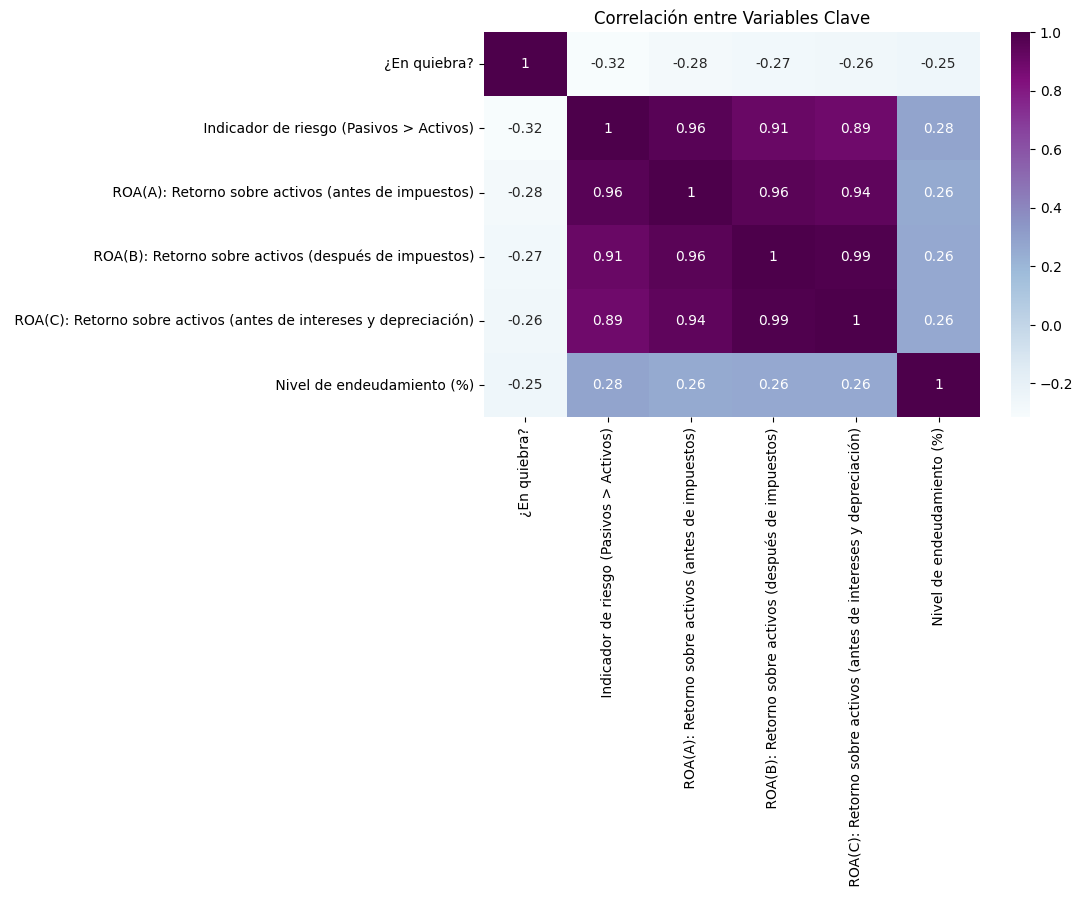

In [5]:
#Top 15 variables correlacionadas con quiebra
corr_target = df.corr()['¿En quiebra?'].abs().sort_values(ascending=False)
print("\nTop 15 variables correlacionadas con quiebra:\n", corr_target[1:16])  # Excluye la variable objetivo

# Heatmap de correlaciones
plt.figure(figsize=(8, 5))
sns.heatmap(df[corr_target.index[:6]].corr(), annot=True, cmap='BuPu')
plt.title("Correlación entre Variables Clave");

In [7]:
# Opción 1: Lista directa
print(df.columns.tolist())

# Opción 2: Con índice (para ver posición + nombre)
for idx, columna in enumerate(df.columns, 1):
    print(f"{idx}. {columna}")

['¿En quiebra?', ' ROA(C): Retorno sobre activos (antes de intereses y depreciación)', ' ROA(A): Retorno sobre activos (antes de impuestos)', ' ROA(B): Retorno sobre activos (después de impuestos)', ' Margen bruto operativo', ' Margen bruto de ventas realizadas', ' Tasa de beneficio operativo', ' Tasa de interés neto (antes de impuestos)', ' Tasa de interés neto (después de impuestos)', ' Ingresos/gastos no operativos', ' Tasa de interés continua (después de impuestos)', ' % de gastos operativos', ' % de gastos en I+D', ' Ratio de flujo de caja', ' % de deuda con intereses', ' Tasa impositiva (A)', ' Valor contable por acción (B)', ' Valor contable por acción (A)', ' Valor contable por acción (C)', ' EPS persistente (últimos 4 trimestres)', ' Flujo de caja por acción', ' Ingresos por acción (Yuan ¥)', ' Beneficio operativo por acción (Yuan ¥)', ' Beneficio neto por acción (antes de impuestos', ' Yuan ¥)', ' Crecimiento del margen bruto de ventas', ' Crecimiento del beneficio operativo'

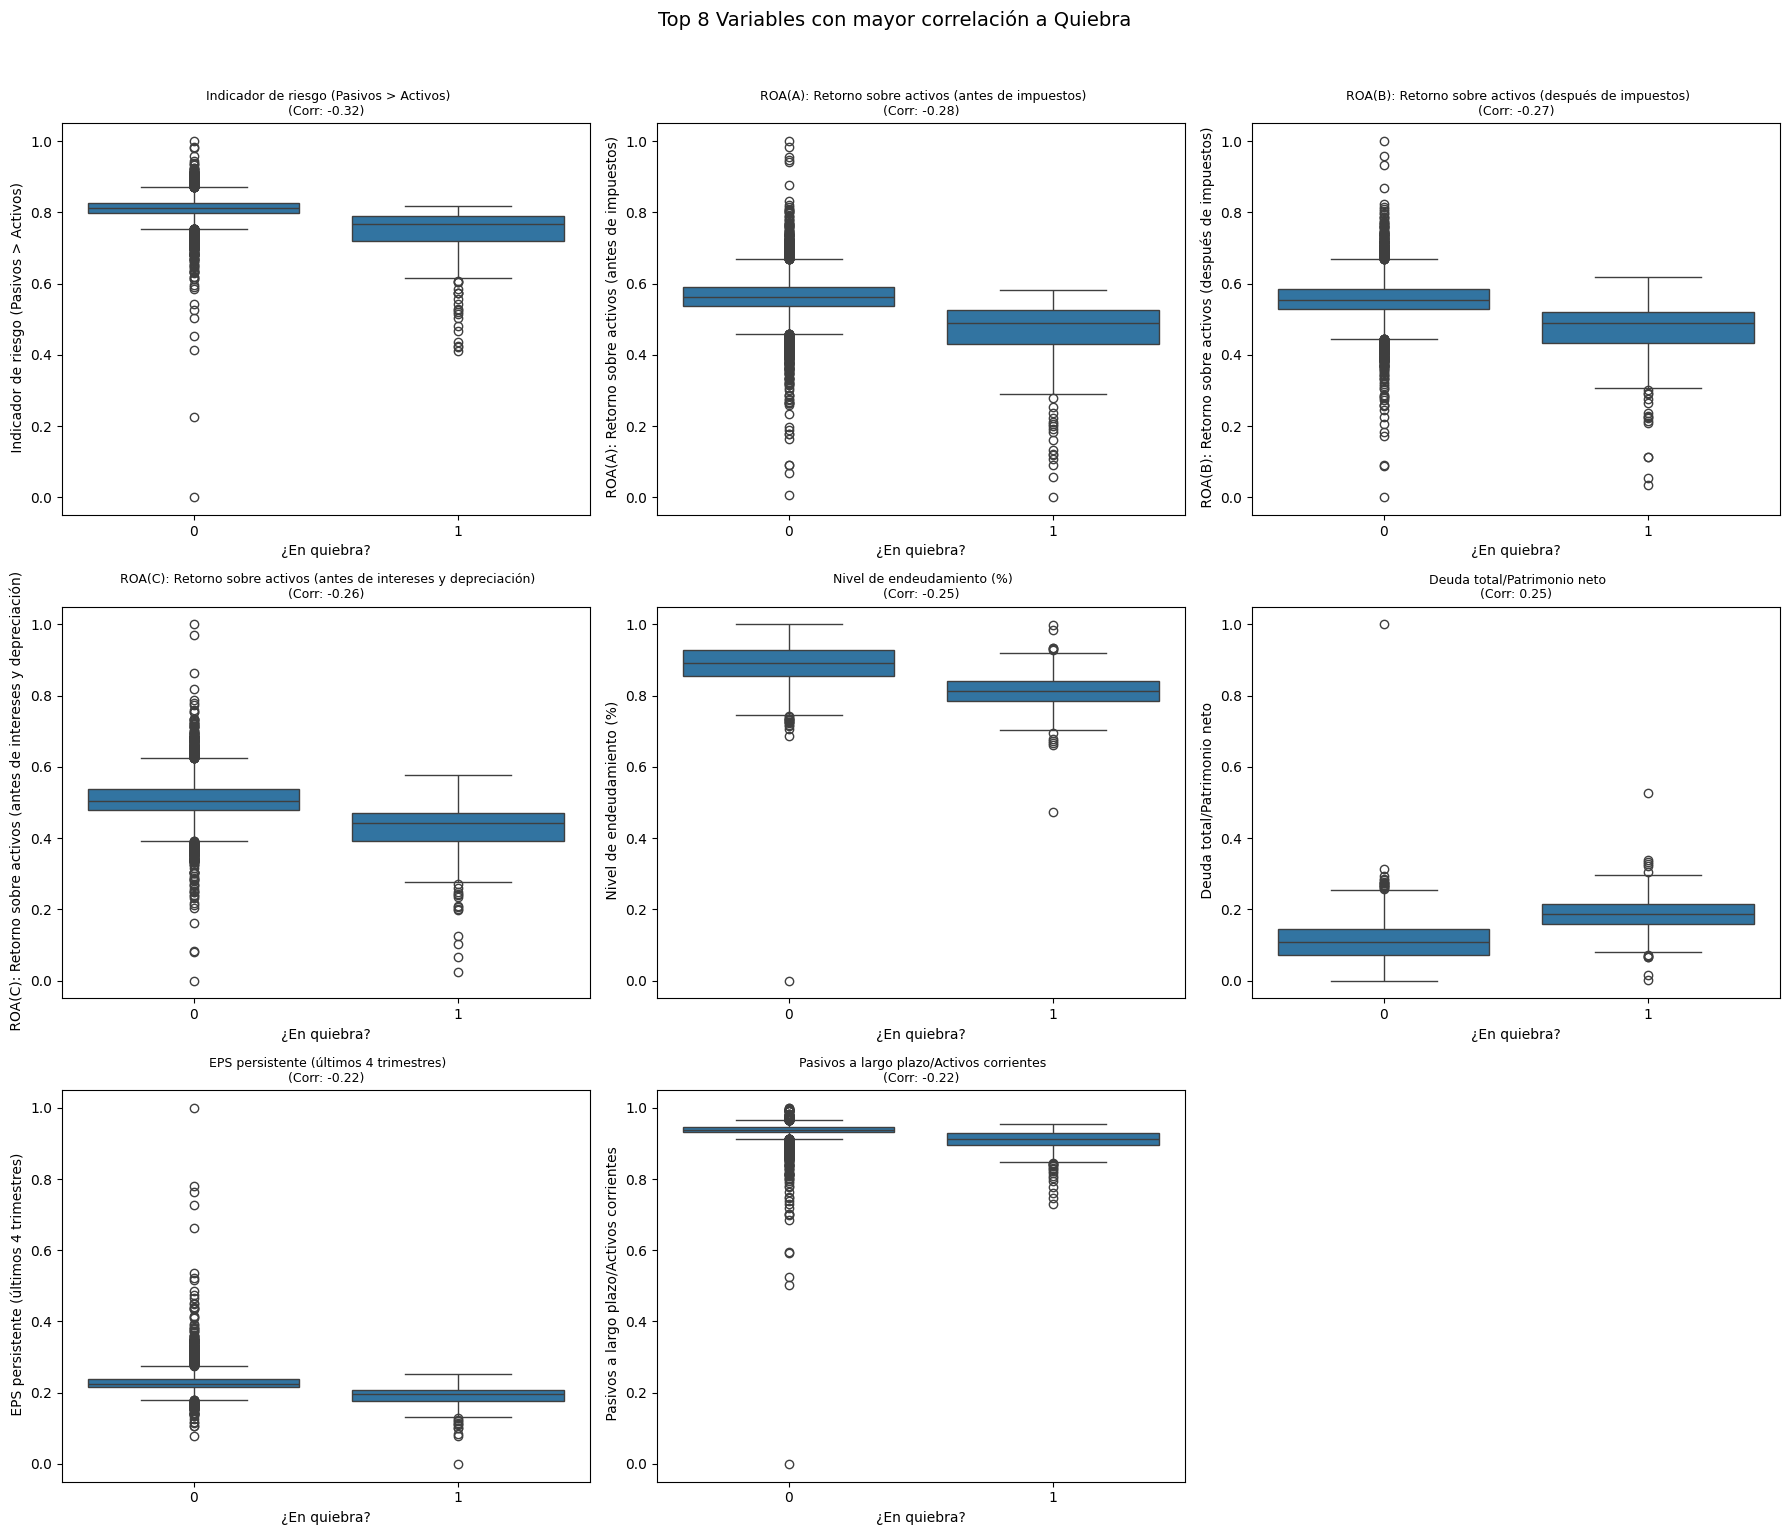

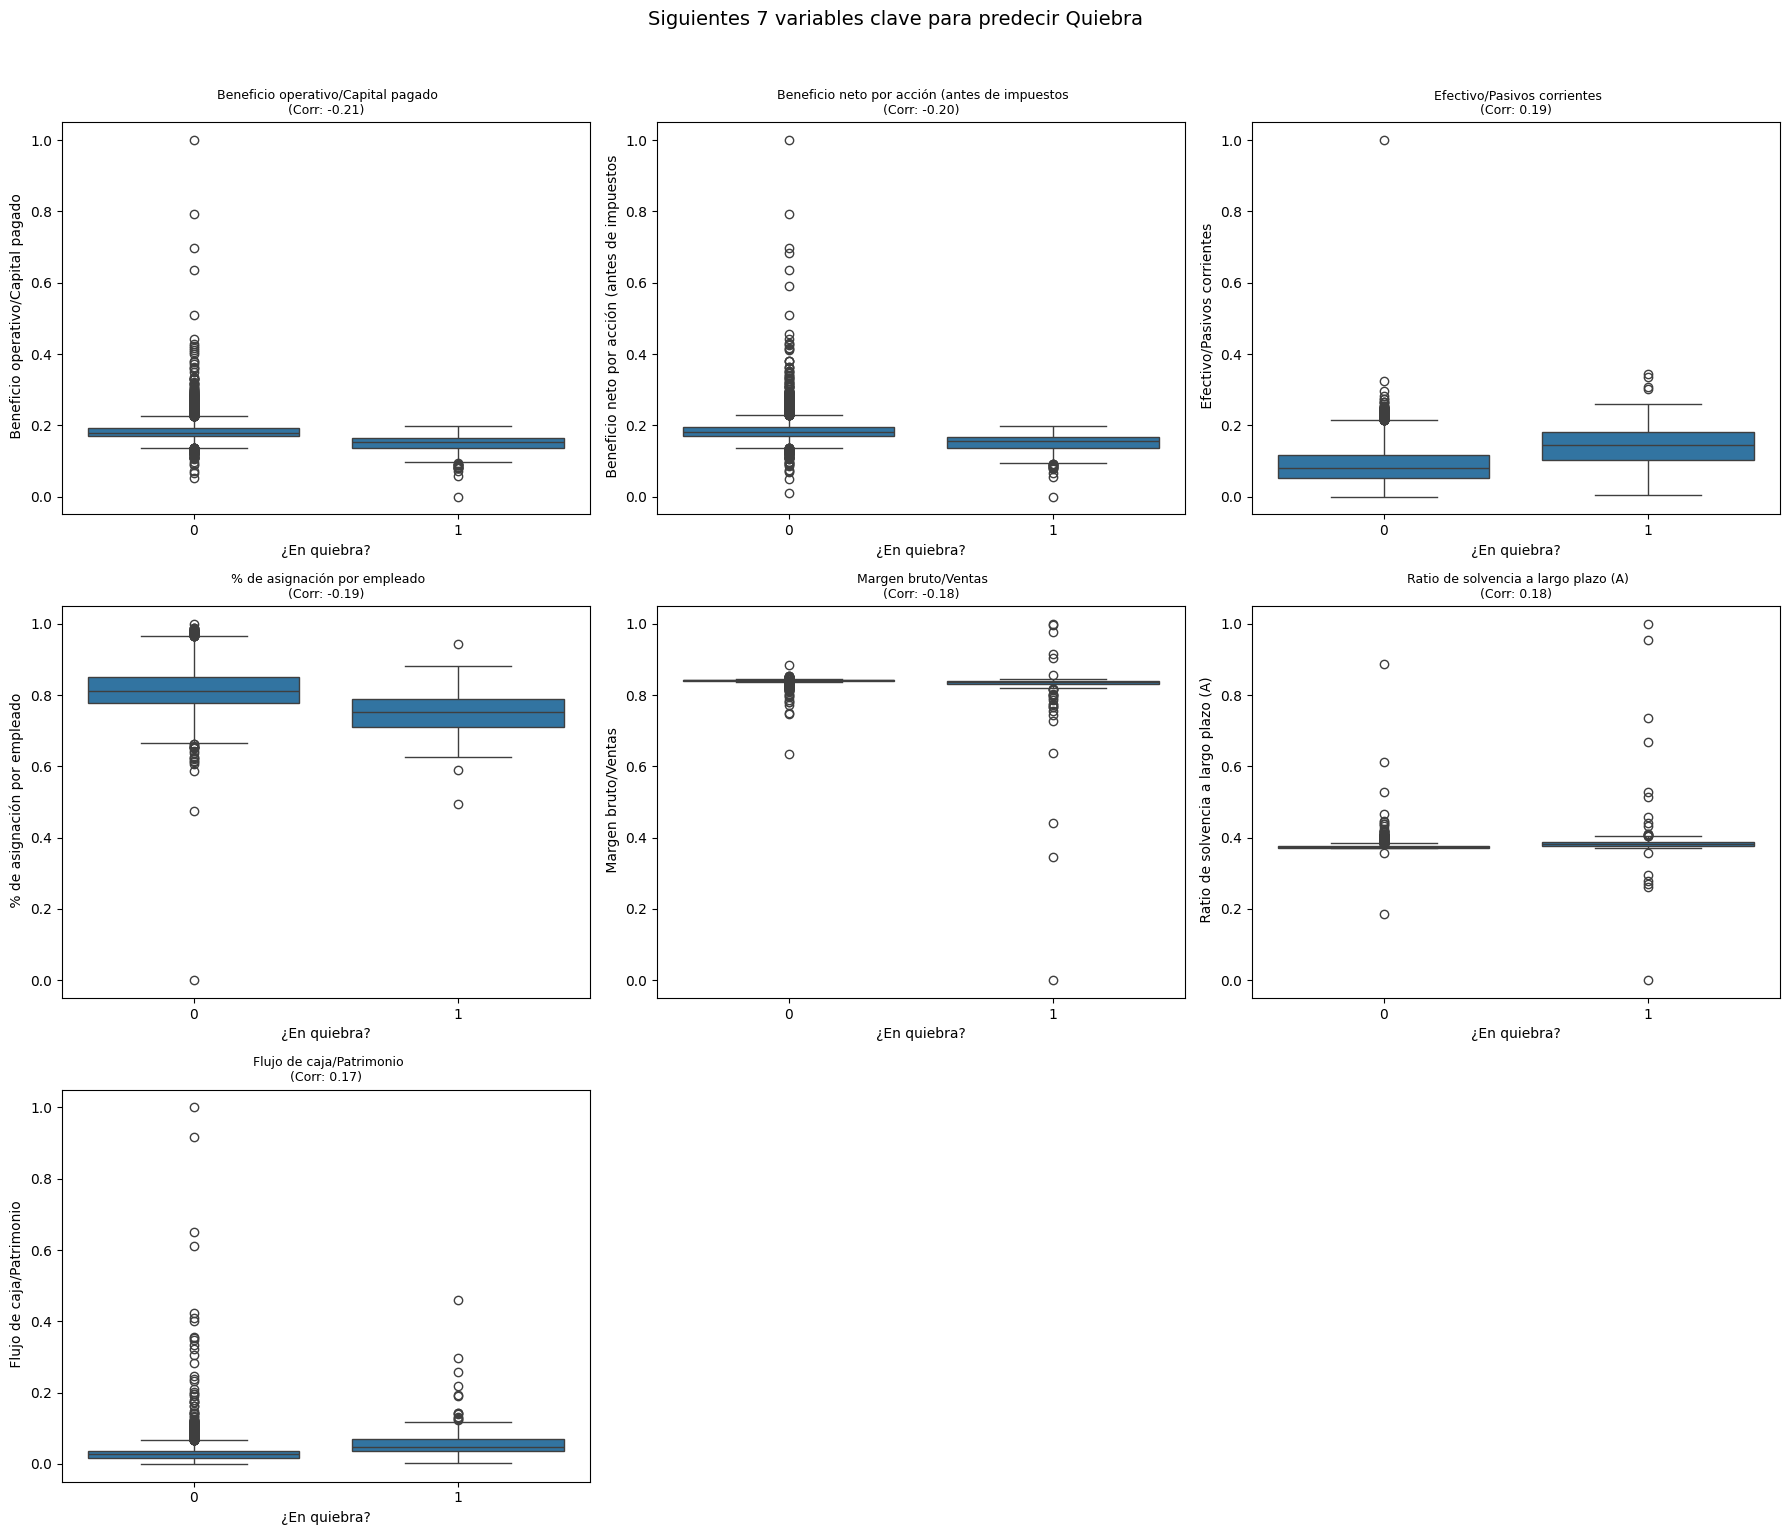

In [8]:
#Distribuimos variables clave
#Recordemos las 15 variables ordenadas por correlación que recien obtuvimos
top_15_vars = [
    ' Indicador de riesgo (Pasivos > Activos)',
    ' ROA(A): Retorno sobre activos (antes de impuestos)',
    ' ROA(B): Retorno sobre activos (después de impuestos)',
    ' ROA(C): Retorno sobre activos (antes de intereses y depreciación)',
    ' Nivel de endeudamiento (%)',
    ' Deuda total/Patrimonio neto',
    ' EPS persistente (últimos 4 trimestres)',
    ' Pasivos a largo plazo/Activos corrientes',
    ' Beneficio operativo/Capital pagado',
    ' Beneficio neto por acción (antes de impuestos',
    ' Efectivo/Pasivos corrientes',
    ' % de asignación por empleado',
    ' Margen bruto/Ventas',
    ' Ratio de solvencia a largo plazo (A)',
    ' Flujo de caja/Patrimonio'
]

# Dividimos las variables en 2 grupos para 2 figuras
grupo1 = top_15_vars[:8]  # Primera figura: 8 variables (3x3)
grupo2 = top_15_vars[8:]  # Segunda figura: 7 variables (3x3)

# Función para generar los plots
def plot_variables(variables, title):
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.ravel()
    for i, var in enumerate(variables):
        sns.boxplot(x='¿En quiebra?', y=var, data=df, ax=axes[i])
        axes[i].set_title(f'{var}\n(Corr: {df[var].corr(df["¿En quiebra?"]):.2f})', fontsize=9)
    # Ocultar ejes vacíos
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Generar las figuras
plot_variables(grupo1, 'Top 8 Variables con mayor correlación a Quiebra')
plot_variables(grupo2, 'Siguientes 7 variables clave para predecir Quiebra')

In [9]:
# Identificamos columnas completamente nulas
null_cols = df.columns[df.isnull().all()].tolist()
print("Columnas completamente nulas:", null_cols)

# Las eliminamos antes de continuar
if null_cols:
    df = df.drop(columns=null_cols)
    print(f"Se eliminaron {len(null_cols)} columnas nulas.")

# Creamos nuevos features
df[' Liquidez vs Endeudamiento'] = df[' Ratio corriente'] / (df[' Deuda total/Patrimonio neto'] + 1e-6)
df[' Eficiencia Operativa'] = df[' Rotación de activos totales'] * df[' Margen bruto operativo']
df[' Solvencia Global'] = df[' Ratio corriente'] + df[' Ratio de solvencia a largo plazo (A)']

# Preparamos el modelo
X = df.drop('¿En quiebra?', axis=1)
y = df['¿En quiebra?']
feature_names = X.columns  # Guardamos los nombres

# Importamos SimpleImputer desde sklearn.impute
from sklearn.impute import SimpleImputer

# Imputamos (sin perder nombres)
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=feature_names)

# Seleccionamos features
# Importamos SelectKBest y f_classif
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X_imputed, y)

# Nombres de features seleccionadas
selected_features = feature_names[selector.get_support()]
print("\nTop 20 features predictivas:\n", selected_features)

Columnas completamente nulas: [' Patrimonio/Pasivos']
Se eliminaron 1 columnas nulas.

Top 20 features predictivas:
 Index([' ROA(C): Retorno sobre activos (antes de intereses y depreciación)',
       ' ROA(A): Retorno sobre activos (antes de impuestos)',
       ' ROA(B): Retorno sobre activos (después de impuestos)',
       ' Valor contable por acción (B)', ' Valor contable por acción (A)',
       ' Valor contable por acción (C)',
       ' EPS persistente (últimos 4 trimestres)',
       ' Beneficio neto por acción (antes de impuestos',
       ' Deuda total/Patrimonio neto', ' Nivel de endeudamiento (%)',
       ' Ratio de solvencia a largo plazo (A)',
       ' Beneficio operativo/Capital pagado', ' % de asignación por empleado',
       ' Efectivo/Pasivos corrientes',
       ' Pasivos a largo plazo/Activos corrientes',
       ' Pasivos corrientes/Pasivos totales.1', ' Flujo de caja/Patrimonio',
       ' Indicador de riesgo (Pasivos > Activos)', ' Margen bruto/Ventas',
       ' Benefici

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [93] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


👉 Las nuevas features creadas no aparecen en el Top 20 de features seleccionadas. Esto sugiere que podrían no ser tan predictivos como se esperaba.

In [ ]:
# Eliminamos columnas constantes (para evitar warnings)
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
if constant_cols:
    X = X.drop(columns=constant_cols)
    print(f"Columnas constantes eliminadas: {constant_cols}")

# Reemplazamos infinitos (por si acaso)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(X), columns=X.columns)

Columnas constantes eliminadas: [' Cobertura de intereses (EBIT/Gastos financieros)']


In [ ]:
#Preprocesamiento de datos
from sklearn.preprocessing import StandardScaler

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

#Separamos los datos en entrenamiento y prueba

from sklearn.model_selection import train_test_split

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)



In [ ]:
#Construimos y entranmos el modelo
from sklearn.ensemble import RandomForestClassifier

# Modelo
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
#Evaluamos el modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predicciones
y_pred = clf.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.969208211143695

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1320
           1       0.56      0.20      0.30        44

    accuracy                           0.97      1364
   macro avg       0.77      0.60      0.64      1364
weighted avg       0.96      0.97      0.96      1364


Matriz de Confusión:
 [[1313    7]
 [  35    9]]


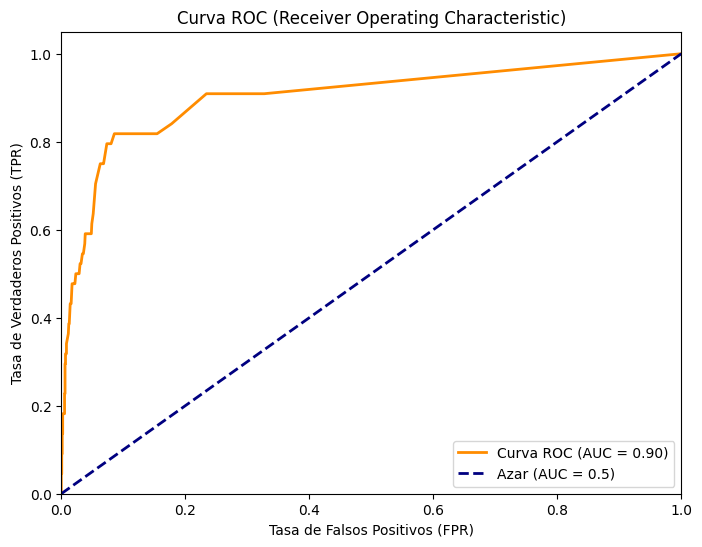

In [ ]:
#HACEMOS ROC y AUC
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades para la clase positiva
y_probs = clf.predict_proba(X_test)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# AUC
roc_auc = roc_auc_score(y_test, y_probs)

# Gráfico
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.show()


In [ ]:
print(f"Área Bajo la Curva ROC (AUC): {roc_auc:.4f}")

Área Bajo la Curva ROC (AUC): 0.9014


☝ La curva ROC permite evaluar la capacidad del modelo para distinguir entre las clases, en este caso, empresas en quiebra y empresas que no estan en quiebra.

El Área Bajo la Curva obtenida es de 0.9, lo que indica un rendimiento muy alto del modelo.
Este valor sugiere que el modelo Random Forest tiene una excelente capacidad para discriminar entre ambas clases, logrando una correcta clasificación en la mayoría de los casos.

Recordando que un AUC de 0.5 representa un modelo sin capacidad predictiva (equivalente al azar), y que un AUC de 1 sería una clasificación perfecta, el valor obtenido refleja que el modelo es altamente efectivo para esta tarea de clasificación. 😉

<ipython-input-31-2af0f9fcd710>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis', legend=False)


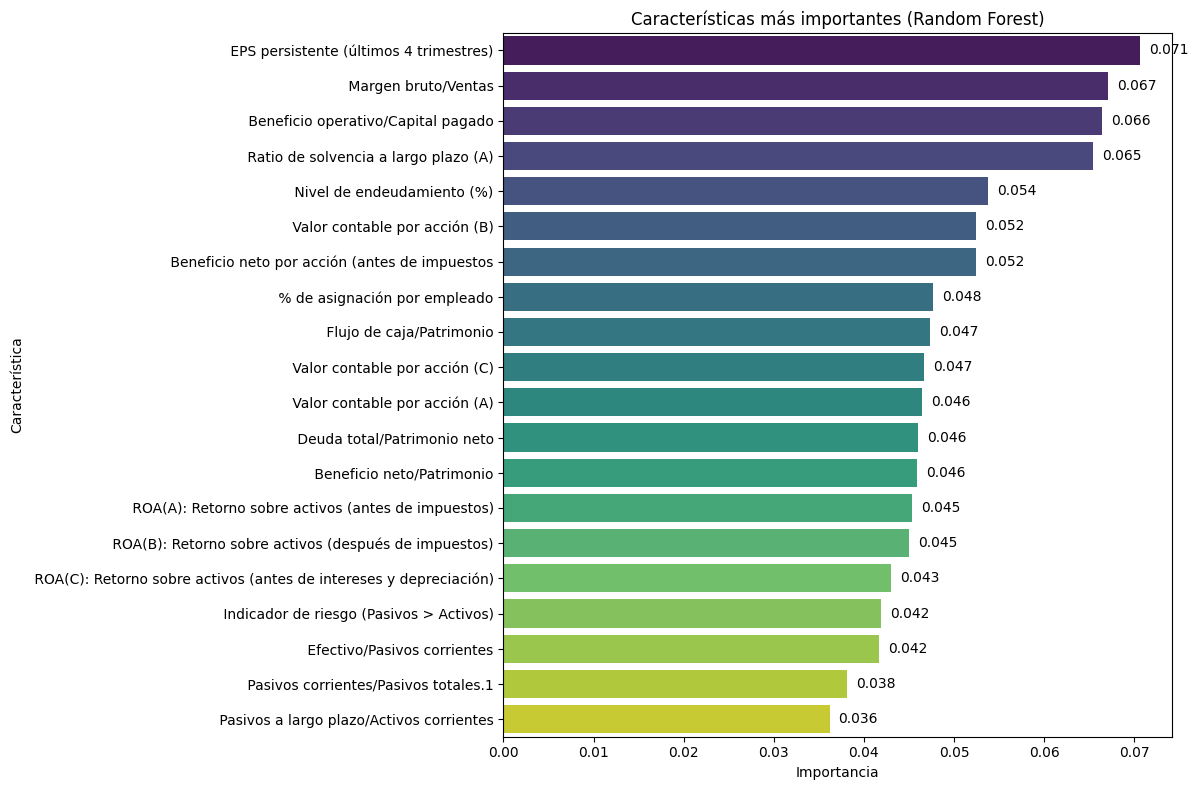

In [ ]:
#Analizamos importancia de las características
import matplotlib.pyplot as plt
import seaborn as sns

# Importancia de features
importancias = clf.feature_importances_
features_finales = selected_features  # Porque usamos solo las seleccionadas

# Gráfico de importancia
feat_imp = pd.Series(importancias, index=features_finales).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis', legend=False)
plt.title('Características más importantes (Random Forest)')
plt.xlabel('Importancia')
plt.ylabel('Característica')

# Mostrar valores al final de cada barra
for i, v in enumerate(feat_imp.values):
    ax.text(v + 0.001, i, f"{v:.3f}", color='black', va='center')

plt.tight_layout()
plt.show()


In [ ]:
print("📊 Resumen de Resultados del Modelo")
print("----------------------------------")
print(f"- Accuracy del modelo en el conjunto de prueba: {0.9692:.4f}")
print(f"- Área Bajo la Curva ROC (AUC): {0.9014:.4f}")

print("\n🔍 Reporte de Clasificación:")
print("- Clase 0 (No quiebra): Precisión = 0.97, Recall = 0.99, F1-Score = 0.98")
print("- Clase 1 (Quiebra): Precisión = 0.56, Recall = 0.20, F1-Score = 0.30")

print("\n📉 Observaciones:")
print("- El modelo predice muy bien la clase mayoritaria (No quiebra).")
print("- Tiene dificultades para identificar correctamente las empresas en quiebra (Clase 1), con baja Recall y F1-Score.")
print("- Esto puede deberse a un desbalance en las clases (solo 44 casos positivos sobre 1364 totales).")

print("\n📌 Top 20 variables más predictivas según el modelo:")
top_features = [
    'ROA(C): Retorno sobre activos (antes de intereses y depreciación)',
    'ROA(A): Retorno sobre activos (antes de impuestos)',
    'ROA(B): Retorno sobre activos (después de impuestos)',
    'Valor contable por acción (B)',
    'Valor contable por acción (A)',
    'Valor contable por acción (C)',
    'EPS persistente (últimos 4 trimestres)',
    'Beneficio neto por acción (antes de impuestos',
    'Deuda total/Patrimonio neto',
    'Nivel de endeudamiento (%)',
    'Ratio de solvencia a largo plazo (A)',
    'Beneficio operativo/Capital pagado',
    '% de asignación por empleado',
    'Efectivo/Pasivos corrientes',
    'Pasivos a largo plazo/Activos corrientes',
    'Pasivos corrientes/Pasivos totales.1',
    'Flujo de caja/Patrimonio',
    'Indicador de riesgo (Pasivos > Activos)',
    'Margen bruto/Ventas',
    'Beneficio neto/Patrimonio'
]
for i, var in enumerate(top_features, 1):
    print(f"{i:>2}. {var}")


📊 Resumen de Resultados del Modelo
----------------------------------
- Accuracy del modelo en el conjunto de prueba: 0.9692
- Área Bajo la Curva ROC (AUC): 0.9014

🔍 Reporte de Clasificación:
- Clase 0 (No quiebra): Precisión = 0.97, Recall = 0.99, F1-Score = 0.98
- Clase 1 (Quiebra): Precisión = 0.56, Recall = 0.20, F1-Score = 0.30

📉 Observaciones:
- El modelo predice muy bien la clase mayoritaria (No quiebra).
- Tiene dificultades para identificar correctamente las empresas en quiebra (Clase 1), con baja Recall y F1-Score.
- Esto puede deberse a un desbalance en las clases (solo 44 casos positivos sobre 1364 totales).

📌 Top 20 variables más predictivas según el modelo:
 1. ROA(C): Retorno sobre activos (antes de intereses y depreciación)
 2. ROA(A): Retorno sobre activos (antes de impuestos)
 3. ROA(B): Retorno sobre activos (después de impuestos)
 4. Valor contable por acción (B)
 5. Valor contable por acción (A)
 6. Valor contable por acción (C)
 7. EPS persistente (últimos 4 tr

# **Conclusiones y comentarios finales** 🔎 🎓

**Validacion de hipótesis**

Recordemos que inicialmente se habian hecho la ssiguientes hiótesis:

**H1)** Las variables relacionadas con deuda ** (X36 - Deuda Total/Patrimonio Neto), **liquidez (X33 - Ratio de Liquidez Corriente) y rentabilidad (X1 - ROA) serán las más relevantes para predecir quiebras.

**H2) **Es posible predecir la quiebra de las empresas con una precisión superior al 75% y un AUC superior a 0.5 utilizando las características proporcionadas y un modelo de Random Forest.

**Analisis de H1:**

El modelo de clasificación ha confirmado parcialmente la hipótesis H1. En particular, las variables de deuda y rentabilidad (ROA) han mostrado una alta relevancia para la predicción de quiebras, lo que coincide con lo planteado inicialmente. Sin embargo, la liquidez (Ratio de Liquidez Corriente) no se ha identificado como una de las variables más predictivas, lo que sugiere que, en este caso, otros factores podrían tener un mayor impacto en la predicción de quiebras.

Este hallazgo podría estar relacionado con características específicas del dataset utilizado, donde otras variables, aunque relacionadas con la liquidez, podrían haber aportado mayor valor predictivo. Por lo tanto, aunque la liquidez teóricamente es importante, no parece ser tan determinante en comparación con la deuda y la rentabilidad.

**Análisis de H2:**

Respecto a la hipótesis H2, podemos concluir que el modelo de Random Forest ha superado ampliamente los umbrales establecidos, alcanzando una precisión del 96.92% y un AUC de 0.9014, lo que indica que el modelo es altamente efectivo para predecir quiebras. Este resultado no solo valida la hipótesis H2, sino que también demuestra que el modelo puede ser una herramienta sólida para predecir eventos de quiebra en base a las características disponibles.